<a href="https://colab.research.google.com/github/Gr1lledChee5e/OthersDataStuff/blob/main/digital_signature_CNN(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image classification using CNN

Let's use Keras on the MNIST data set again, this time using a Convolutional Neural Network that's better suited for image processing.

The MNIST dataset is an acronym that stands for the Modified National Institute of Standards and Technology dataset. It is a dataset of 60,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9. The task is to classify a given image of a handwritten digit into one of 10 classes representing integer values from 0 to 9, inclusively.

With a multi-layer perceptron, we achieved around 97% accuracy. Let's see if we can beat that.

##### The following are common layers for image classification using CNN:

#####  Conv2D: convolution layer for extracting image features (edges, patterns).

#####  MaxPooling2D: downsampling layer to reduce spatial size and keep strong features.

#####  Flatten: converts a 2D feature map into a 1D vector (so it can go into Dense layers).

#####  Dense: fully connected layer (common for final classification).

#####  Dropout: regularization layer that randomly “drops” some neurons during training to reduce overfitting.

In [ ]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt

We'll load up our raw data set exactly as before:

Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


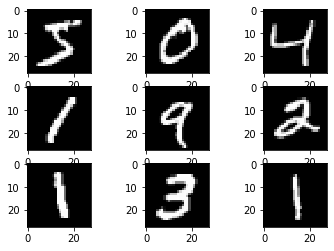

In [ ]:
# load dataset
(trainX, trainY), (testX, testY) = mnist.load_data()
# summarize loaded dataset
print('Train: X=%s, y=%s' % (trainX.shape, trainY.shape))
print('Test: X=%s, y=%s' % (testX.shape, testY.shape))

# plot first few images
## loop over i = 0..8 (9 images)
for i in range(9):
# define subplot
## plt.subplot(331) is interpreted as:3 rows, 3 columns, subplot #1 (position 1)
    plt.subplot(330 + 1 + i)
# plot raw pixel data
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))
# show the figure
plt.show()

We need to shape the data differently than before. Since we're treating the data as 2D images of 28x28 pixels instead of a flattened stream of 784 pixels, we need to shape it accordingly. In 28x28x1, "1" indicates a single color channel, as this is just grayscale. If we were dealing with color images, it would be 3 instead of 1 since we'd have red, green, and blue color channels.

#### Convolution layers (Conv2D) expect image input in 4D form:
#### (number_of_images, height, width, channels) ← “channels-last” format
#### MNIST images are grayscale, so:
#### channels = 1 (not 3 like RGB)
#### trainX.shape[0]: this is the number of images (samples). For MNIST it’s 60000 for training and 10000 #### for test.

In [ ]:
# reshape dataset to have a single channel
trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
testX = testX.reshape((testX.shape[0], 28, 28, 1))

We also know that there are 10 classes and that classes are represented as unique integers.

We use a one hot encoding for the class element of each sample, transforming the integer into a 10 element binary vector with a 1 for the index of the class value, and 0 values for all other classes.

In [ ]:
## Convert digit labels (0–9) into one-hot encoded vectors,
## which is the format commonly used for multi-class classification with neural networks.
trainY = tensorflow.keras.utils.to_categorical(trainY,10)
testY = tensorflow.keras.utils.to_categorical(testY, 10)

#### Prepare Pixel Data
We know that the pixel values for each image in the dataset are unsigned integers in the range between black and white, or 0 and 255.

A good starting point is to normalize the pixel values of grayscale images, e.g. rescale them to the range [0,1]. This involves first converting the data type from unsigned integers to floats, then dividing the pixel values by the maximum value.

In [ ]:
# convert from integers to floats
train_norm = trainX.astype('float32')
test_norm = testX.astype('float32')
# normalize to range 0-1
train_norm = train_norm / 255.0
test_norm = test_norm / 255.0

####  Specify CNN model

The model has two main aspects: the feature extraction front end comprised of convolutional and pooling layers, and the classifier backend that will make a prediction.

For the convolutional front-end, we can start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. The filter maps can then be flattened to provide features to the classifier.

#### Convolutional layer
input_shape=(28, 28, 1): each image is 28×28 with 1 channel (grayscale).

Conv2D(32, (3,3)): applies 32 different 3×3 filters to detect patterns like edges and strokes.

activation='relu': ReLU adds non-linearity and helps learning.

kernel_initializer='he_uniform': good initializer for ReLU networks (helps stable training).

The kernel_initializer parameter is used to specify the method for initializing the weights. The he_uniform initializer is particularly useful for networks with ReLU (Rectified Linear Unit) activation functions.  

After conv: 26×26×32
(because 28 − 3 + 1 = 26)

#### MaxPooling layer
MaxPooling2D((2, 2) then reduces the spatial size by taking the max value in each 2×2 block.
Input: 26×26×32

Output: 13×13×32

#### Flatten (convert 2D feature maps to 1D)
Flatten() layer is used to convert the multi-dimensional output of a convolutional or pooling layer into a one-dimensional vector.  This is necessary before passing the data to fully connected (dense) layers for classification or regression tasks.

Input: 13×13×32

Flattened size: 13 × 13 × 32 = 5408

Output: (5408,) per image

#### Dense hidden layer (learn combinations of features)

Creates a fully-connected layer with 100 neurons

Uses ReLU + He initialization again

Learns higher-level combinations of the extracted CNN features

#### Output layer (10 classes)

10 neurons = 10 digit classes (0–9)

softmax converts outputs into probabilities that sum to 1.


In [ ]:
   model = Sequential()

   model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
   model.add(MaxPooling2D((2, 2)))
   model.add(Flatten())
   model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
   model.add(Dense(10, activation='softmax'))

In [ ]:
   model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 100)               540900    
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1010      
Total params: 542,230
Trainable params: 542,230
Non-trainable params: 0
_________________________________________________________________


We will use a conservative configuration for the stochastic gradient descent optimizer with a learning rate of 0.01 and a momentum of 0.9. The categorical cross-entropy loss function will be optimized, suitable for multi-class classification, and we will monitor the classification accuracy metric, which is appropriate given we have the same number of examples in each of the 10 classes.

##### momentum=0.9: helps speed up training and reduces zig-zagging.

Momentum keeps part of the previous update direction, smoothing and accelerating movement in consistent directions.

In [ ]:
 # compile model
opt = SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_norm, trainY,
                    batch_size=32,
                    epochs=10,
                    verbose=2,
                    validation_data=(test_norm, testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 - 17s - loss: 0.1722 - acc: 0.9476 - val_loss: 0.0810 - val_acc: 0.9749
Epoch 2/10
60000/60000 - 19s - loss: 0.0602 - acc: 0.9817 - val_loss: 0.0486 - val_acc: 0.9844
Epoch 3/10
60000/60000 - 18s - loss: 0.0385 - acc: 0.9881 - val_loss: 0.0502 - val_acc: 0.9841
Epoch 4/10
60000/60000 - 18s - loss: 0.0256 - acc: 0.9927 - val_loss: 0.0439 - val_acc: 0.9859
Epoch 5/10
60000/60000 - 18s - loss: 0.0190 - acc: 0.9944 - val_loss: 0.0436 - val_acc: 0.9859
Epoch 6/10
60000/60000 - 18s - loss: 0.0129 - acc: 0.9964 - val_loss: 0.0462 - val_acc: 0.9856
Epoch 7/10
60000/60000 - 18s - loss: 0.0096 - acc: 0.9974 - val_loss: 0.0456 - val_acc: 0.9858
Epoch 8/10
60000/60000 - 18s - loss: 0.0057 - acc: 0.9987 - val_loss: 0.0441 - val_acc: 0.9870
Epoch 9/10
60000/60000 - 18s - loss: 0.0041 - acc: 0.9991 - val_loss: 0.0480 - val_acc: 0.9863
Epoch 10/10
60000/60000 - 18s - loss: 0.0028 - acc: 0.9995 - val_loss: 0.0511 - val_acc: 0.9868

Was it worth the wait?

In [ ]:
score = model.evaluate(test_norm, testY, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.05113651463133628
Test accuracy: 0.9868


Over 98.68%! And that's with just 10 epochs! And from the looks of it, 4 or 5 would have been enough. It came at a significant cost in terms of computing power, but when you start distributing things over multiple computers each with multiple GPU's, that cost starts to feel less bad. If you're building something where life and death are on the line, like a self-driving car, every fraction of a percent matters.